# Import Libraries & Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [23]:
# handling missing values
df.replace(" ", np.nan, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)


In [49]:
# Dropping Customer ID
df.drop(['customerID'], axis=1, inplace=True)


# Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Churn Distribution')

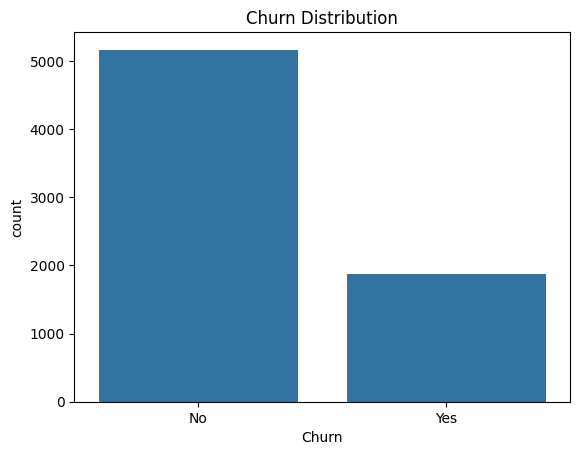

In [27]:
# Churn Distributin
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")


Text(0.5, 1.0, 'Contract Type vs Churn')

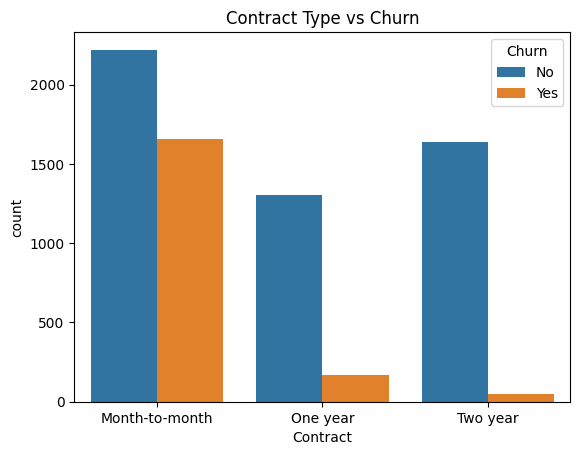

In [28]:
# Churn Vs Contract
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=0)
plt.title("Contract Type vs Churn")


Text(0.5, 1.0, 'Tenure Distribution by Churn')

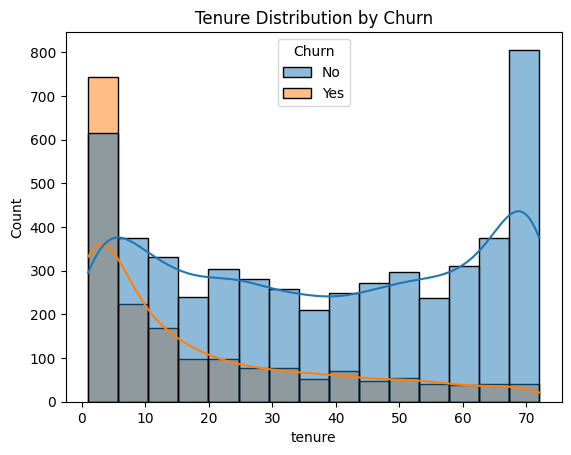

In [29]:
# Churn Vs Tenure
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title("Tenure Distribution by Churn")



<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

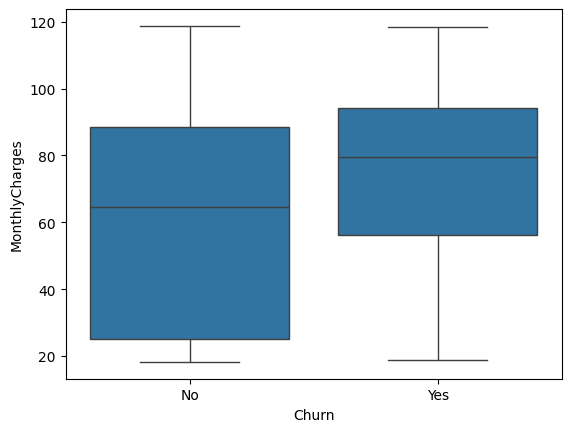

In [30]:
# Churn Vs Monthly Charges
sns.boxplot(y='MonthlyCharges', x='Churn', data=df)


# Feature Encoding + Scaling

In [31]:
# Label Encoding for yes/no columns:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])


In [32]:
# Train-test split
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
feat_imp.head(15)


,feature,importance
0,TotalCharges,0.177577
1,MonthlyCharges,0.154429
2,tenure,0.149276
3,num_services,0.042864
4,InternetService_Fiber optic,0.035666
5,PaymentMethod_Electronic check,0.034790
6,Contract_Two year,0.028649
7,gender_Male,0.027684
8,PaperlessBilling_Yes,0.026013
9,OnlineSecurity_Yes,0.024120


# ML Model Training

In [52]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [37]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [38]:
from xgboost import XGBClassifier

# XGBoost Model
xgb = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


<Figure size 800x550 with 0 Axes>

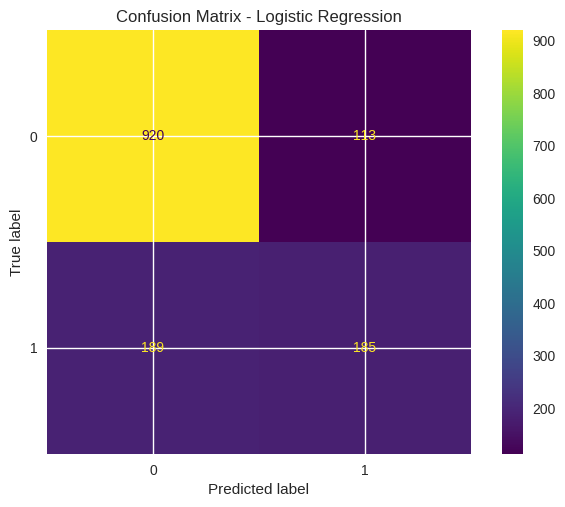


----- Logistic Regression Classification Report -----

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



<Figure size 800x550 with 0 Axes>

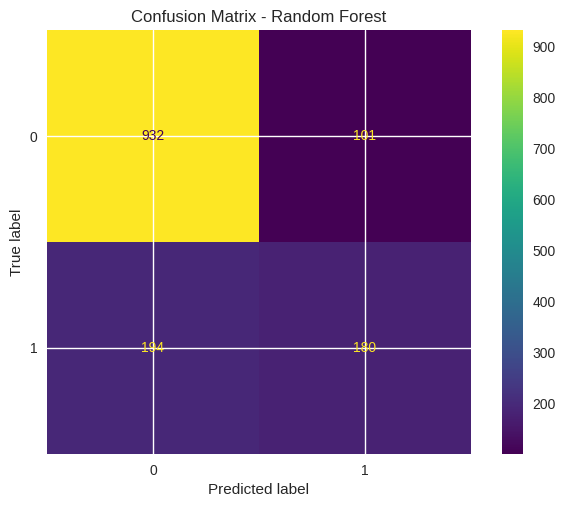


----- Random Forest Classification Report -----

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



<Figure size 800x550 with 0 Axes>

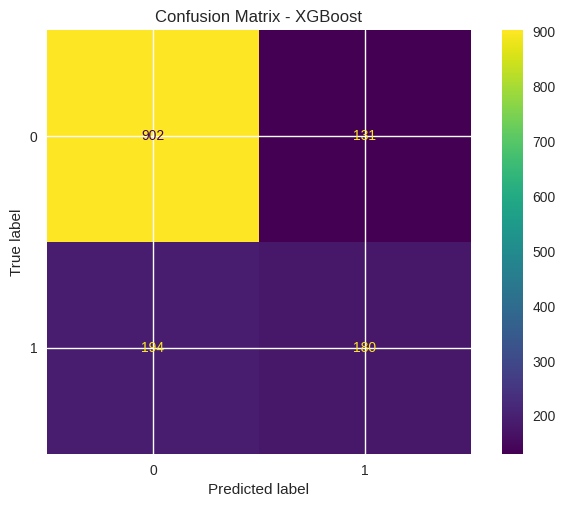


----- XGBoost Classification Report -----

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.58      0.48      0.53       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for model_name, model in models.items():
    plt.figure()
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    print(f"\n----- {model_name} Classification Report -----\n")
    print(classification_report(y_test, y_pred))


# Model Evaluation

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(model):
    pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


In [43]:
evaluate(lr)
evaluate(rf)
evaluate(xgb)


Accuracy: 0.7853589196872779
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

Accuracy: 0.7903340440653873
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Accuracy: 0.7690120824449183
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.58      0.48      0.53       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.

# Explainable AI with SHAP

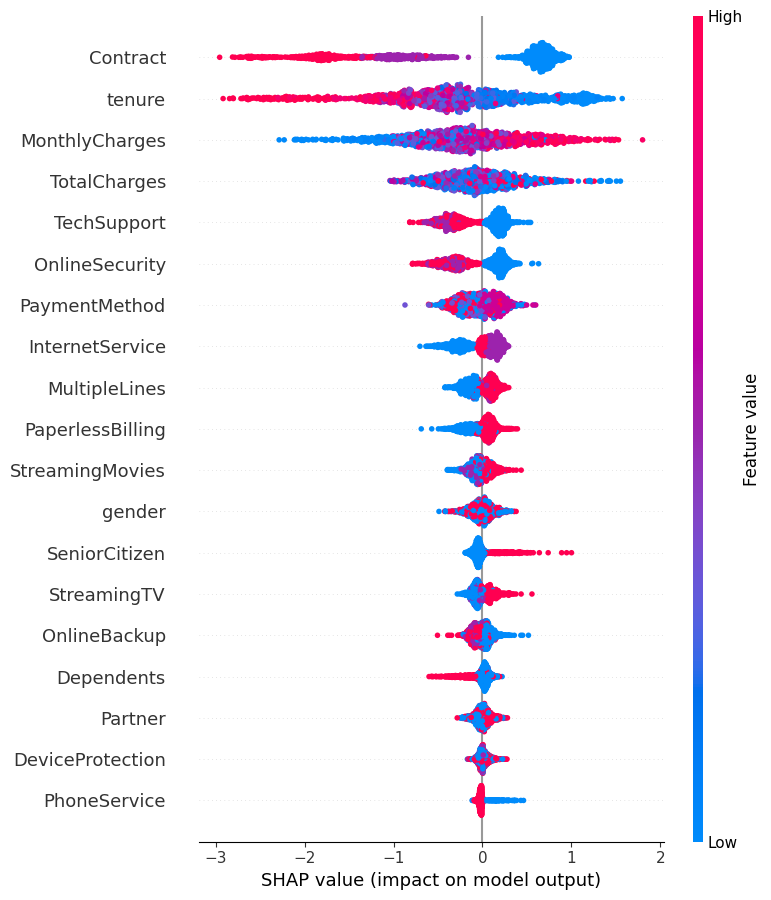

In [40]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [44]:
df_results = X_test.copy()
df_results['Churn_Prob'] = xgb.predict_proba(X_test)[:,1]


In [46]:
df_results['Risk_Segment'] = pd.cut(
    df_results['Churn_Prob'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)


# Customer Segmentation (High, Medium, Low Churn Risk)

Text(0.5, 1.0, 'Customer Risk Segments')

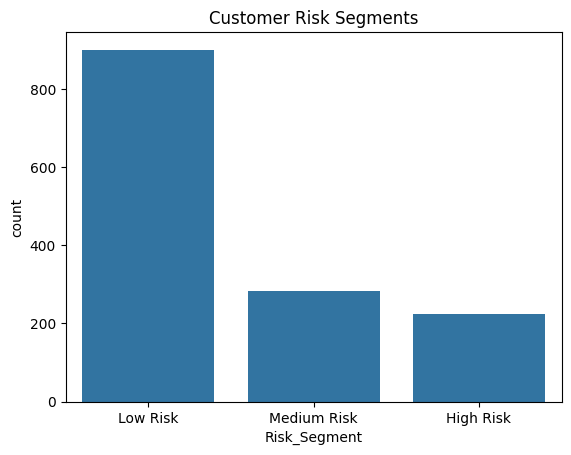

In [47]:
sns.countplot(x=df_results['Risk_Segment'])
plt.title("Customer Risk Segments")


# Matplotlib Dashboard

/tmp/ipython-input-1294094525.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,0], x=df['Churn'], palette="Set2")
/tmp/ipython-input-1294094525.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,0], data=df, y='MonthlyCharges', x='Churn', palette="coolwarm")
/tmp/ipython-input-1294094525.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1,1], x=df_results['Risk_Segment'], palette="viridis")


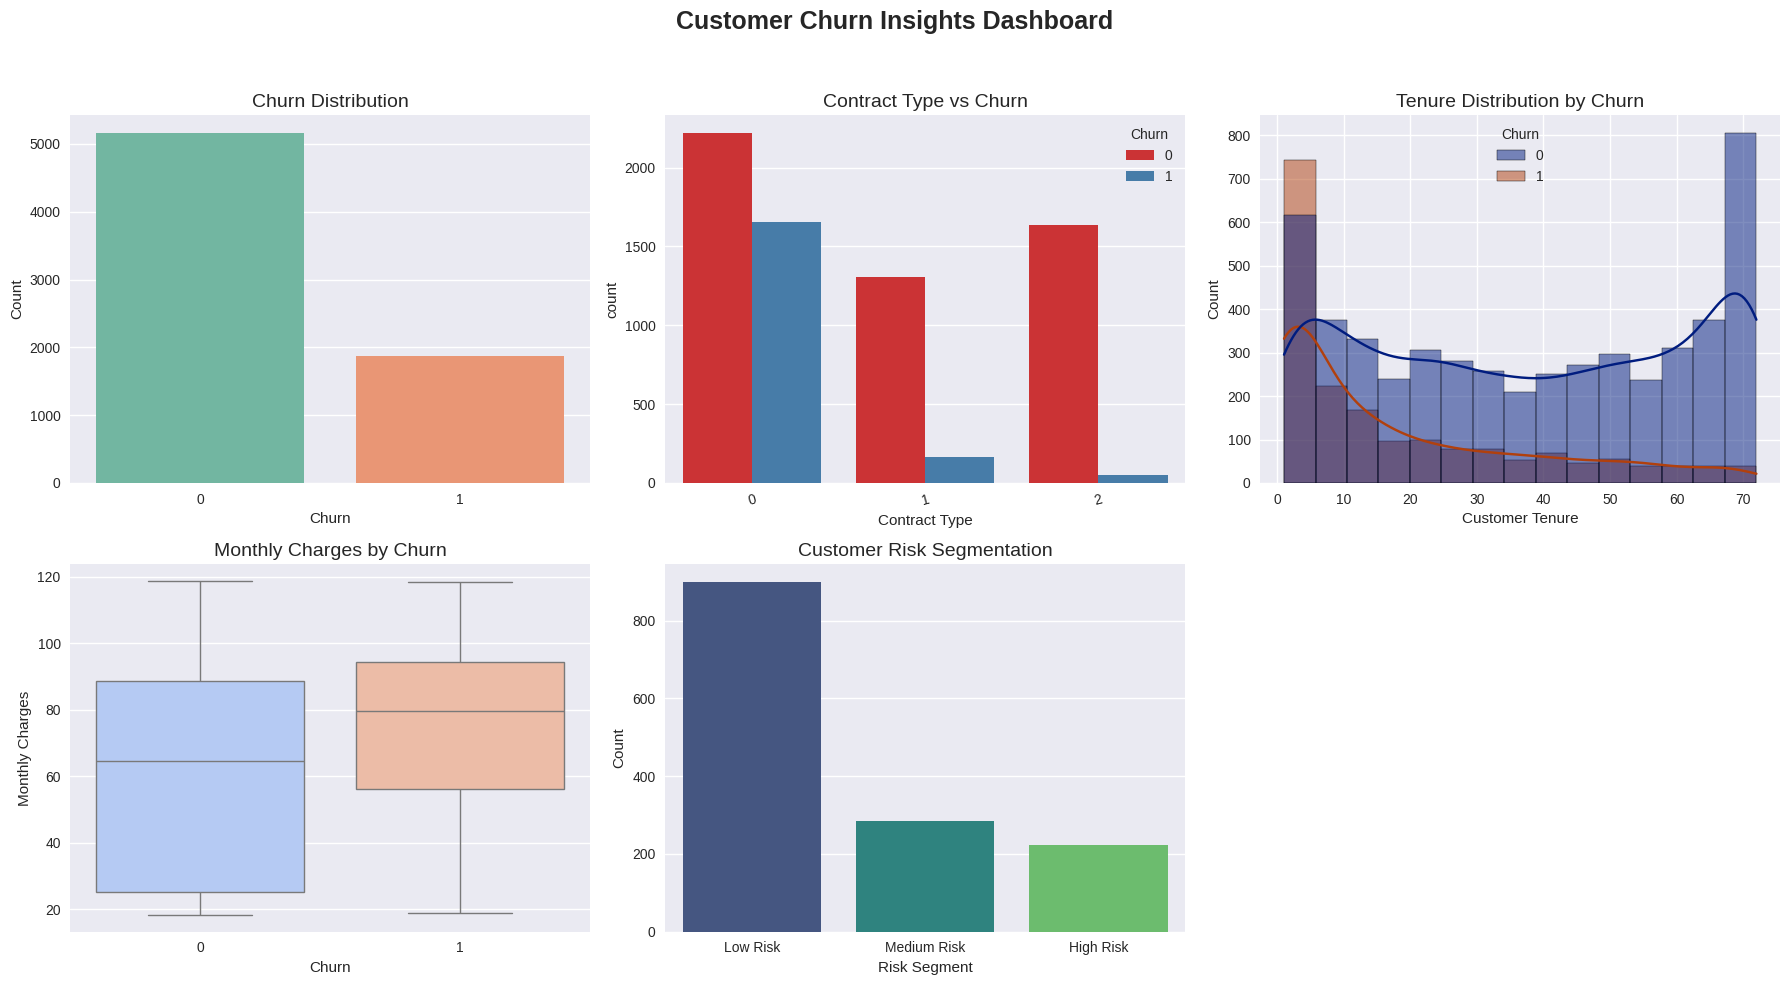

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Customer Churn Insights Dashboard", fontsize=18, fontweight='bold')


# Churn Distribution

sns.countplot(ax=axes[0,0], x=df['Churn'], palette="Set2")
axes[0,0].set_title("Churn Distribution", fontsize=14)
axes[0,0].set_xlabel("Churn")
axes[0,0].set_ylabel("Count")


# Contract Type vs Churn

sns.countplot(ax=axes[0,1], data=df, x='Contract', hue='Churn', palette="Set1")
axes[0,1].set_title("Contract Type vs Churn", fontsize=14)
axes[0,1].set_xlabel("Contract Type")
axes[0,1].tick_params(axis='x', rotation=15)


# Tenure Distribution by Churn

sns.histplot(ax=axes[0,2], data=df, x='tenure', hue='Churn', kde=True, palette="dark")
axes[0,2].set_title("Tenure Distribution by Churn", fontsize=14)
axes[0,2].set_xlabel("Customer Tenure")


# Monthly Charges vs Churn (Boxplot)

sns.boxplot(ax=axes[1,0], data=df, y='MonthlyCharges', x='Churn', palette="coolwarm")
axes[1,0].set_title("Monthly Charges by Churn", fontsize=14)
axes[1,0].set_xlabel("Churn")
axes[1,0].set_ylabel("Monthly Charges")


# Risk Segments (High / Medium / Low)

sns.countplot(ax=axes[1,1], x=df_results['Risk_Segment'], palette="viridis")
axes[1,1].set_title("Customer Risk Segmentation", fontsize=14)
axes[1,1].set_xlabel("Risk Segment")
axes[1,1].set_ylabel("Count")



axes[1,2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
